In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import tqdm

# Biotypes

Use Ensembl database to find gene type for each gene name / symbol:
- in the case where multiple type match the same name (as do not have unique identifier like ENSEMBL ID) take the majority type, but with priority for protein coding
- if no type exists report as a Failure (may be outdated / different naming convention)

## Load data

In [2]:
# reduced to common genes across all days, so can use any d
data_d0 = pd.read_csv("../Data/GSE151334_d0_counts_common.csv", index_col=0)
data_d0.head()

,mESC_EB_d0_A11_S11,mESC_EB_d0_A12_S12,mESC_EB_d0_A13_S13,mESC_EB_d0_A14_S14,mESC_EB_d0_A15_S15,mESC_EB_d0_A16_S16,mESC_EB_d0_A17_S17,mESC_EB_d0_A18_S18,mESC_EB_d0_A19_S19,mESC_EB_d0_A1_S1,...,mESC_EB_d0_P18_S378,mESC_EB_d0_P19_S379,mESC_EB_d0_P1_S361,mESC_EB_d0_P21_S381,mESC_EB_d0_P2_S362,mESC_EB_d0_P3_S363,mESC_EB_d0_P5_S365,mESC_EB_d0_P6_S366,mESC_EB_d0_P8_S368,mESC_EB_d0_P9_S369
Napa,0,494,0,0,0,1,0,0,0,0,...,0,68,40,0,0,0,0,0,674,0
Rsl1d1,0,641,0,3,0,13,0,0,0,0,...,0,100,51,0,2209,1,0,0,760,0
Usp3,0,0,0,7,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Odf2l,0,0,0,0,0,0,0,0,0,0,...,8,0,0,0,0,0,0,0,0,0
Gm26244,0,467,0,370,0,581,0,0,0,134,...,0,292,514,0,0,115,0,0,560,0


## Load Ensembl Data

In [4]:
# Gene data
ensembl_df = pd.read_csv("./mart_export.txt", sep="\t")
ensembl_df.head()

,Transcript type,Gene type,Gene name
0,Mt_tRNA,Mt_tRNA,mt-Tf
1,Mt_rRNA,Mt_rRNA,mt-Rnr1
2,Mt_tRNA,Mt_tRNA,mt-Tv
3,Mt_rRNA,Mt_rRNA,mt-Rnr2
4,Mt_tRNA,Mt_tRNA,mt-Tl1


In [5]:
# Look only at gene name and type
ensembl_df = ensembl_df[['Gene name', 'Gene type']].drop_duplicates().dropna()
ensembl_df.head()

,Gene name,Gene type
0,mt-Tf,Mt_tRNA
1,mt-Rnr1,Mt_rRNA
2,mt-Tv,Mt_tRNA
3,mt-Rnr2,Mt_rRNA
4,mt-Tl1,Mt_tRNA


In [6]:
# select data gene names
data_gene_names = list(data_d0.index)

# for each gene name
data_gene_types = []
for name in tqdm.tqdm(data_gene_names):

    # select all associated gene types
    gene_types = ensembl_df[ensembl_df['Gene name'] == name]['Gene type']

    # no data
    if len(gene_types) == 0:
        data_gene_types.append("Failure")

    # unique type
    elif len(gene_types) == 1:
        data_gene_types.append(gene_types.iloc[0])

    # multiple types
    # protein coding priority
    elif "protein_coding" in gene_types:
        data_gene_types.append("protein_coding")

    # else majority
    else:
        data_gene_types.append(gene_types.value_counts().index[0])

100%|██████████| 7558/7558 [00:34<00:00, 219.46it/s]


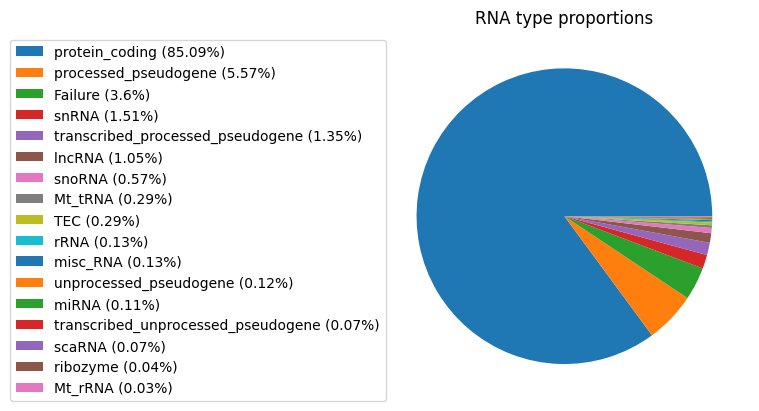

In [7]:
# display proportions of RNA types
types, counts = np.unique(data_gene_types, return_counts=True)
sort_idx = np.argsort(-counts)
types = types[sort_idx]
counts = counts[sort_idx]
plt.pie(counts)
plt.legend(loc=(-1, 0), labels=[f"{name} ({round(100 * count / data_d0.shape[0], 2)}%)" for name, count in zip(types, counts)])
plt.title("RNA type proportions")
plt.show()

## Manual check

In [25]:
# see if any genes with "Mir" in their names which do not have type miRNA
mi_names = [name for name in data_gene_names if "Mir" in name]
mi_types_not = []
mi_names_not = []
for name in mi_names:
    idx = list(data_gene_names).index(name)
    btype = data_gene_types[idx]
    if btype != "miRNA":
        mi_types_not.append(btype)
        mi_names_not.append(name)

In [26]:
# display
for name, btype in zip(mi_names_not, mi_types_not):
    print(f"{name} | {btype}")

Mirg | lncRNA


`Mirg` is an "miRNA containing gene" but transcribes lncRNA, so should not be considered an miRNA (?)

## Save Biotypes

In [27]:
# construct dictionary
biotypes_dict = {name: btype for name, btype in zip(data_gene_names, data_gene_types)}

In [28]:
# save
with open('biotypes_common.json', 'w') as f:
    json.dump(biotypes_dict, f)